## COMPAS - 2 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42
#seed = 13

In [5]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [8]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=2,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([0.5, 0.5]))

### MOLA

22:24:09 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:24:09 | DEBUG | machinemoo | Finding 1th individual minimum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:24:09 | DEBUG | machinemoo | Finding 2th individual minimum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_m

new solution added [0.61283158 0.61719796]


/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:24:09 | DEBUG | machinemoo | Calculated weights: [0.25295799 0.74704201]
22:24:09 | DEBUG | machinemoo | Importance: 0.00043194097557319733
22:24:09 | DEBUG | machinemoo | Global lower bound (y*): [0.61260705 0.61662356]
22:24:09 | DEBUG | machinemoo | Iteration 2
22:24:09 | DEBUG | machinemoo | Solutions list: [array([0.61283158, 0.61719796]), array([0.61260705, 0.618978

new solution added [0.61351914 0.61673736]


/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:24:09 | DEBUG | machinemoo | Calculated weights: [0.40116465 0.59883535]
22:24:09 | DEBUG | machinemoo | Importance: 0.0002837367737942298
22:24:09 | DEBUG | machinemoo | Global lower bound (y*): [0.61260705 0.61662356]
22:24:09 | DEBUG | machinemoo | Iteration 3
22:24:09 | DEBUG | machinemoo | Solutions list: [array([0.61351914, 0.61673736]), array([0.61283158, 0.6171979

...

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:24:35 | DEBUG | machinemoo | Calculated weights: [0.64773146 0.35226854]
22:24:35 | DEBUG | machinemoo | Importance: 3.852182933972159e-05
22:24:35 | DEBUG | machinemoo | Global lower bound (y*): [0.61246839 0.61661719]
22:24:35 | DEBUG | machinemoo | Iteration 148
22:24:35 | DEBUG | machinemoo | Solutions list: [array([0.61267355, 0.61742669]), array([0.61253648, 0.61776

new solution added [0.61267496 0.61742401]


/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:24:35 | DEBUG | machinemoo | Calculated weights: [0.64867557 0.35132351]
22:24:35 | DEBUG | machinemoo | Importance: 3.873193606512837e-05
22:24:35 | DEBUG | machinemoo | Global lower bound (y*): [0.61246839 0.61661719]
22:24:35 | DEBUG | machinemoo | Iteration 149
22:24:35 | DEBUG | machinemoo | Solutions list: [array([0.61267496, 0.61742401]), array([0.61267355, 0.61742

new solution added [0.61267397 0.61742584]


/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
22:24:35 | DEBUG | machinemoo | Calculated weights: [0.64867562 0.35132351]
22:24:35 | DEBUG | machinemoo | Importance: 3.872487073913744e-05
22:24:35 | DEBUG | machinemoo | Global lower bound (y*): [0.61246839 0.61661719]
22:24:35 | DEBUG | machinemoo | Iteration 150
22:24:35 | DEBUG | machinemoo | Solutions list: [array([0.61267397, 0.61742584]), array([0.61267496, 0.61742

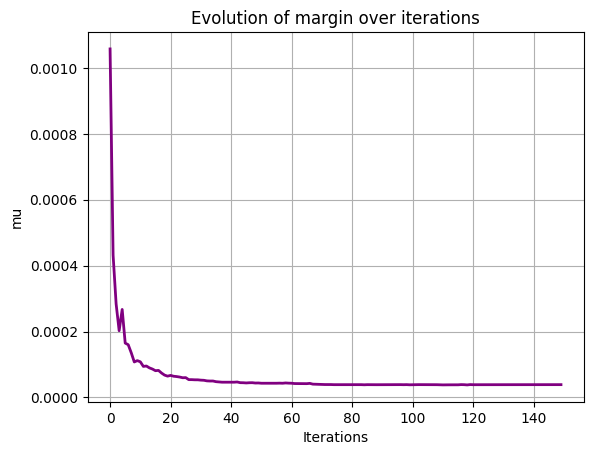

22:24:35 | INFO | machinemoo | Fit runtime: 26.70 seconds


In [9]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

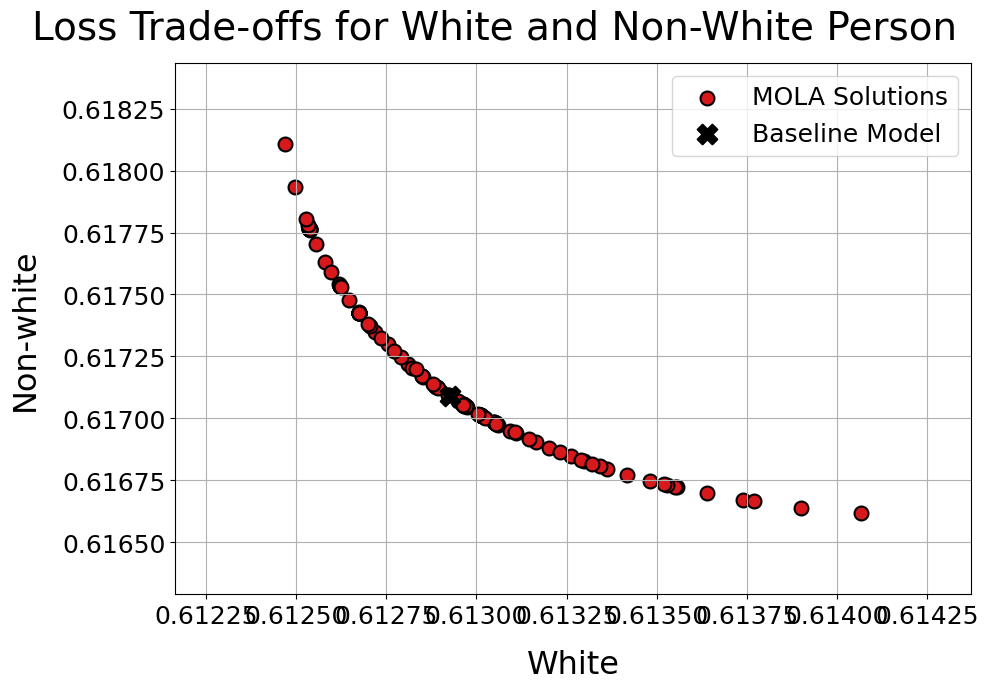

In [10]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            # color="#FF5C8D",
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola.pdf'
            )

In [11]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto_plotly(methods={'mola': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            color=['#FF5C8D', '#4BD6A0', '#9D5CFF'],
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_plotly.pdf'
            )

22:24:36 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
22:24:36 | DEBUG | machinemoo | Finding 1th individual minimum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:24:36 | DEBUG | machinemoo | Finding 2th individual minimum
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceW

gradi  [[-0.00126095 -0.00138519 -0.00111434  0.00017886  0.00020547  0.        ]
 [-0.07124063 -0.00450192 -0.00401619  0.00862664  0.00217202 -0.00381989]]
gradi  [[ 0.03538432  0.00179208  0.00173589 -0.01036543 -0.0039813   0.        ]
 [ 0.00156326 -0.00082794  0.00074228  0.00015303 -0.00075292  0.00080767]]


22:24:36 | DEBUG | machinemoo | Calculated weights: [4.76835966e-07 9.99999523e-01]
22:24:36 | DEBUG | machinemoo | Importance: 0.008055956861603656
22:24:36 | DEBUG | machinemoo | Global lower bound (y*): [0.61176478 0.60856759]
22:24:36 | DEBUG | machinemoo | Iteration 1
22:24:36 | DEBUG | machinemoo | Solutions list: [array([0.61260705, 0.6189783 ]), array([0.61452791, 0.61662356])]
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:24:36 | INFO | machi

gradi  [[ 3.7886642e-02  3.6077355e-03  1.5261237e-03 -9.9910591e-03
  -2.0598092e-03  0.0000000e+00]
 [-6.6898973e-04 -8.4700703e-05 -4.8914808e-07  2.7484508e-05
   1.2025790e-04  1.7664464e-04]]
new solution added [0.61450396 0.61659467]
solution dominated [0.61452791 0.61662356]


22:24:36 | DEBUG | machinemoo | Calculated weights: [4.79757703e-07 9.99999520e-01]
22:24:36 | DEBUG | machinemoo | Importance: 0.00802706529916911
22:24:36 | DEBUG | machinemoo | Global lower bound (y*): [0.61139435 0.60856759]
22:24:36 | DEBUG | machinemoo | Iteration 2
22:24:36 | DEBUG | machinemoo | Solutions list: [array([0.61450396, 0.61659467]), array([0.61260705, 0.6189783 ])]
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:24:36 | INFO | machin

...

gradi  [[ 3.8876195e-02  3.7956836e-03  1.5840596e-03 -9.9542709e-03
  -2.0531323e-03  0.0000000e+00]
 [ 5.8847945e-08 -2.9685907e-09 -2.5611371e-09 -3.7834980e-09
  -7.2031980e-09 -3.5797711e-09]]
new solution dominated [0.6145303  0.61659402]


22:24:37 | DEBUG | machinemoo | Calculated weights: [3.02311218e-07 9.99999698e-01]
22:24:37 | DEBUG | machinemoo | Importance: 0.008026420526326399
22:24:37 | DEBUG | machinemoo | Global lower bound (y*): [0.61126715 0.60856759]
22:24:37 | DEBUG | machinemoo | Iteration 43
22:24:37 | DEBUG | machinemoo | Solutions list: [array([0.6145303 , 0.61659402]), array([0.61450396, 0.61659467]), array([0.61260705, 0.6189783 ])]
22:24:37 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.61126715 0.60856759]


gradi  [[ 3.8876150e-02  3.7956813e-03  1.5840591e-03 -9.9542709e-03
  -2.0531365e-03  0.0000000e+00]
 [-2.8667273e-08 -4.0454324e-09 -3.3760443e-09 -4.7002686e-09
  -9.7352313e-09 -1.5614205e-08]]
new solution added [0.6145303  0.61659402]


22:24:37 | DEBUG | machinemoo | Calculated weights: [3.02311210e-07 9.99999698e-01]
22:24:37 | DEBUG | machinemoo | Importance: 0.00802642052632629
22:24:37 | DEBUG | machinemoo | Global lower bound (y*): [0.61126715 0.60856759]
22:24:37 | DEBUG | machinemoo | Iteration 44
22:24:37 | DEBUG | machinemoo | Solutions list: [array([0.6145303 , 0.61659402]), array([0.6145303 , 0.61659402]), array([0.61450396, 0.61659467]), array([0.61260705, 0.6189783 ])]
22:24:37 | INFO | machinemoo | Best solution found.


gradi  [[ 3.8876150e-02  3.7956813e-03  1.5840591e-03 -9.9542709e-03
  -2.0531365e-03  0.0000000e+00]
 [-2.8667273e-08 -4.0454324e-09 -3.3760443e-09 -4.7002686e-09
  -9.7352313e-09 -1.5614205e-08]]


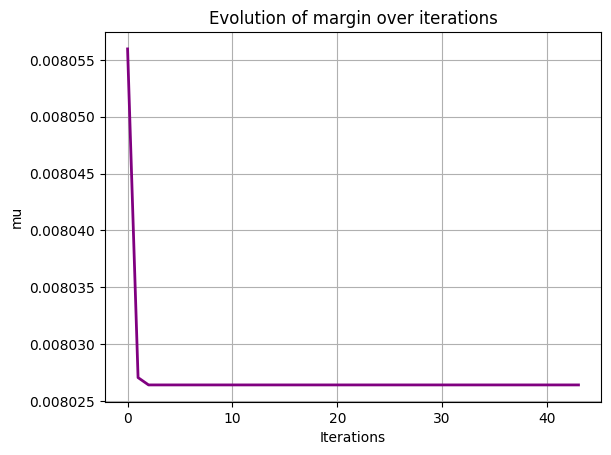

22:24:37 | INFO | machinemoo | Fit runtime: 1.15 seconds


In [12]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

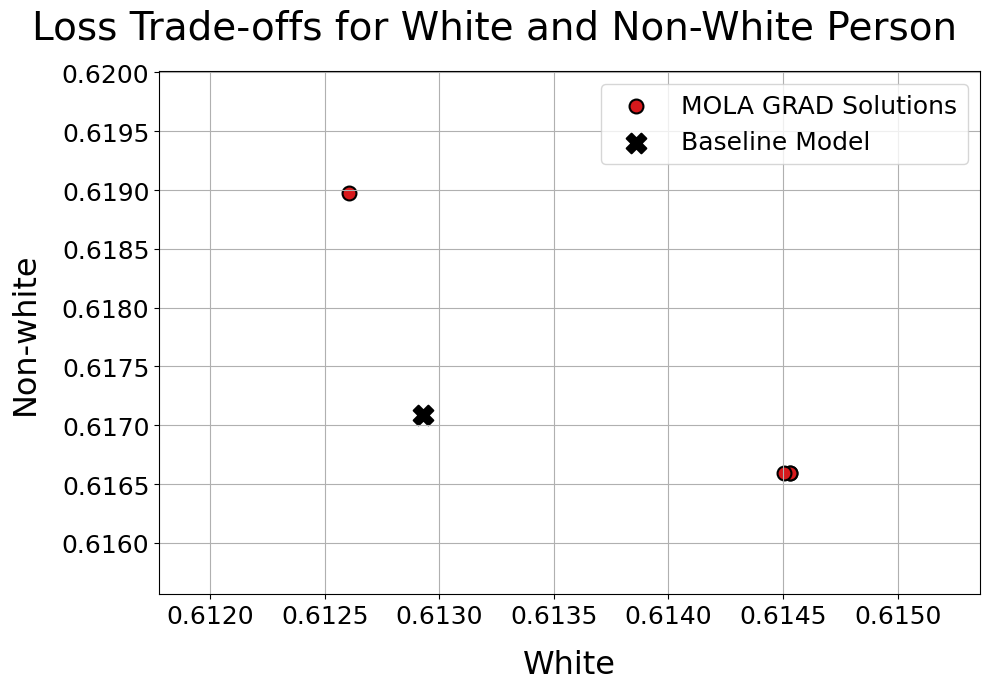

In [13]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola_grad': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad.pdf'
            )

In [14]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto_plotly(methods={'mola_grad': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            #color="#FF5C8D",
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad_plotly.pdf'
            )

### MONISE

In [30]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

22:26:19 | DEBUG | machinemoo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 150, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
22:26:19 | DEBUG | machinemoo | Finding 1th individual minima


/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:26:19 | DEBUG | machinemoo | Finding 2th individual minima
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale t

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:26:19 | DEBUG | machinemoo | 13th solution - importance: 0.02395151471955217
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might al

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


...

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:26:42 | DEBUG | machinemoo | 149th solution - importance: 0.0019503697665320579


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:26:43 | DEBUG | machinemoo | 150th solution - importance: 0.0019503697665320579


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Ramdon Weighted Sum

In [16]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

22:25:08 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeGap', 'targetGap', 'nodeTimeLimit'}
22:25:08 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
22:25:08 | DEBUG | machinemoo | Finding 1th individual minima
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

22:25:08 | DEBUG | machinemoo | Finding 2th individual minima
/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [17]:
from machinemoo.tests.experiments.run import run_experiments

### Color test

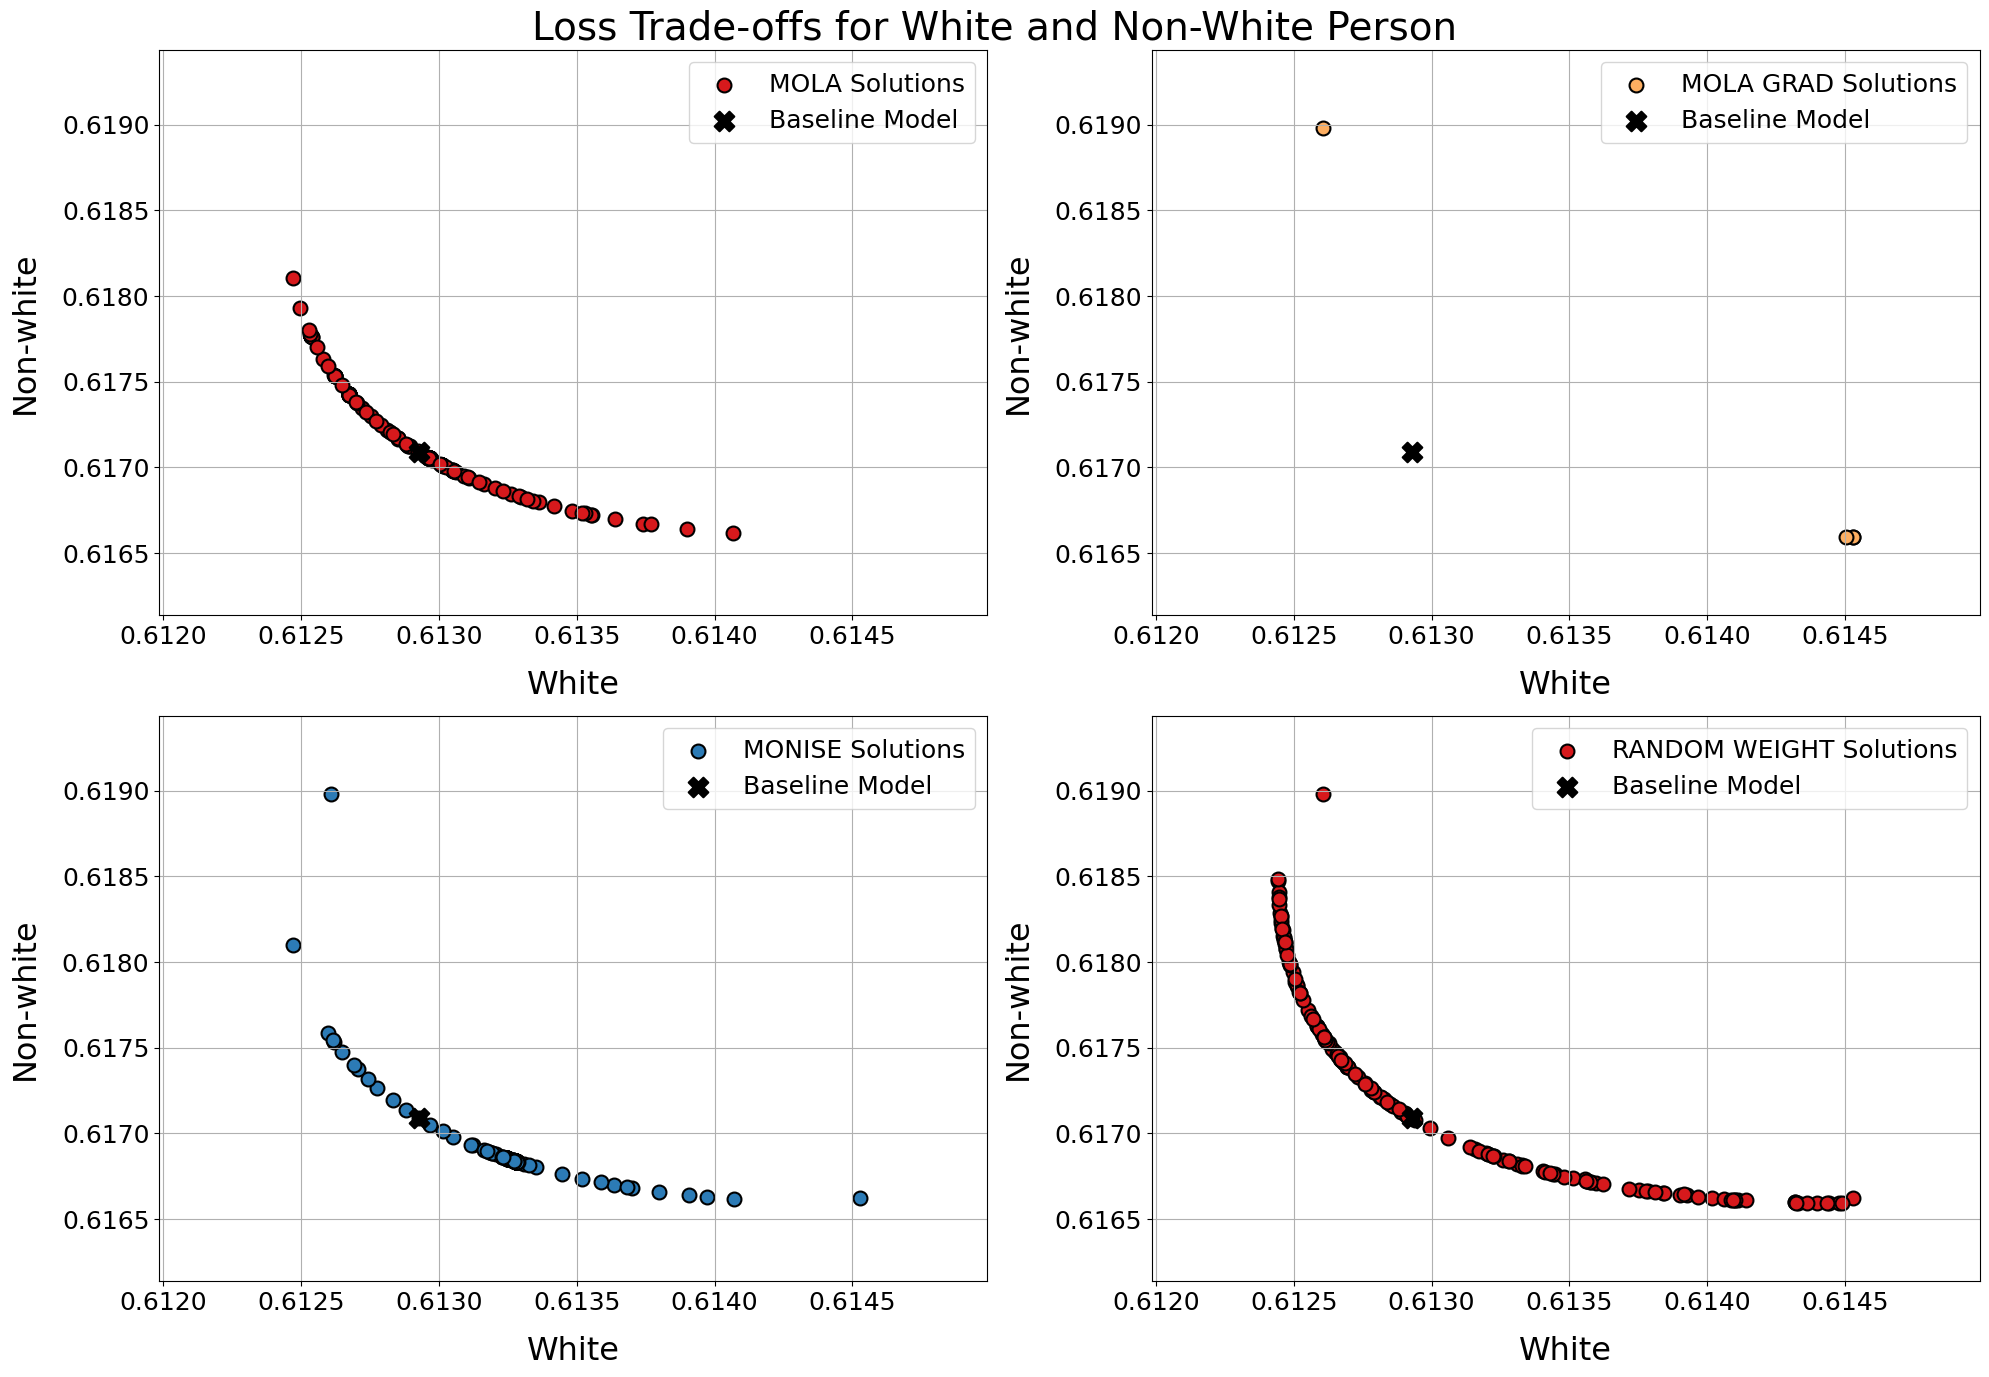

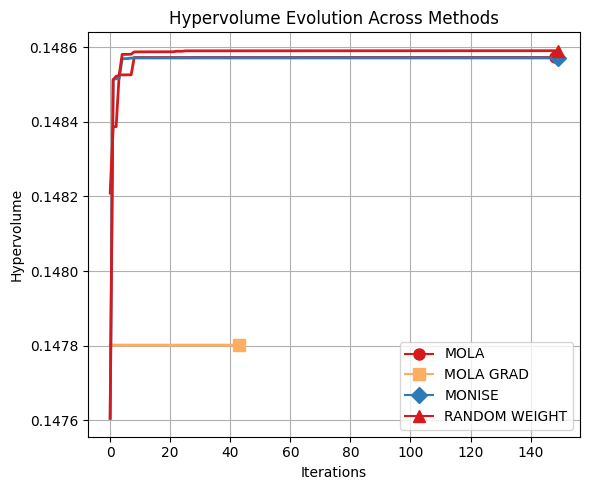

In [18]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#FF5C8D', '#4BD6A0', '#9D5CFF']
axes_label = ["White", "Non-White"]

plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            # color="#FF5C8D",
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods.pdf'
            )

plot_pareto_plotly(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            # color="#FF5C8D",
            fontsize=15,
            figsize=(10,7),
            save_path='images/2_objs_methods_plotly.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

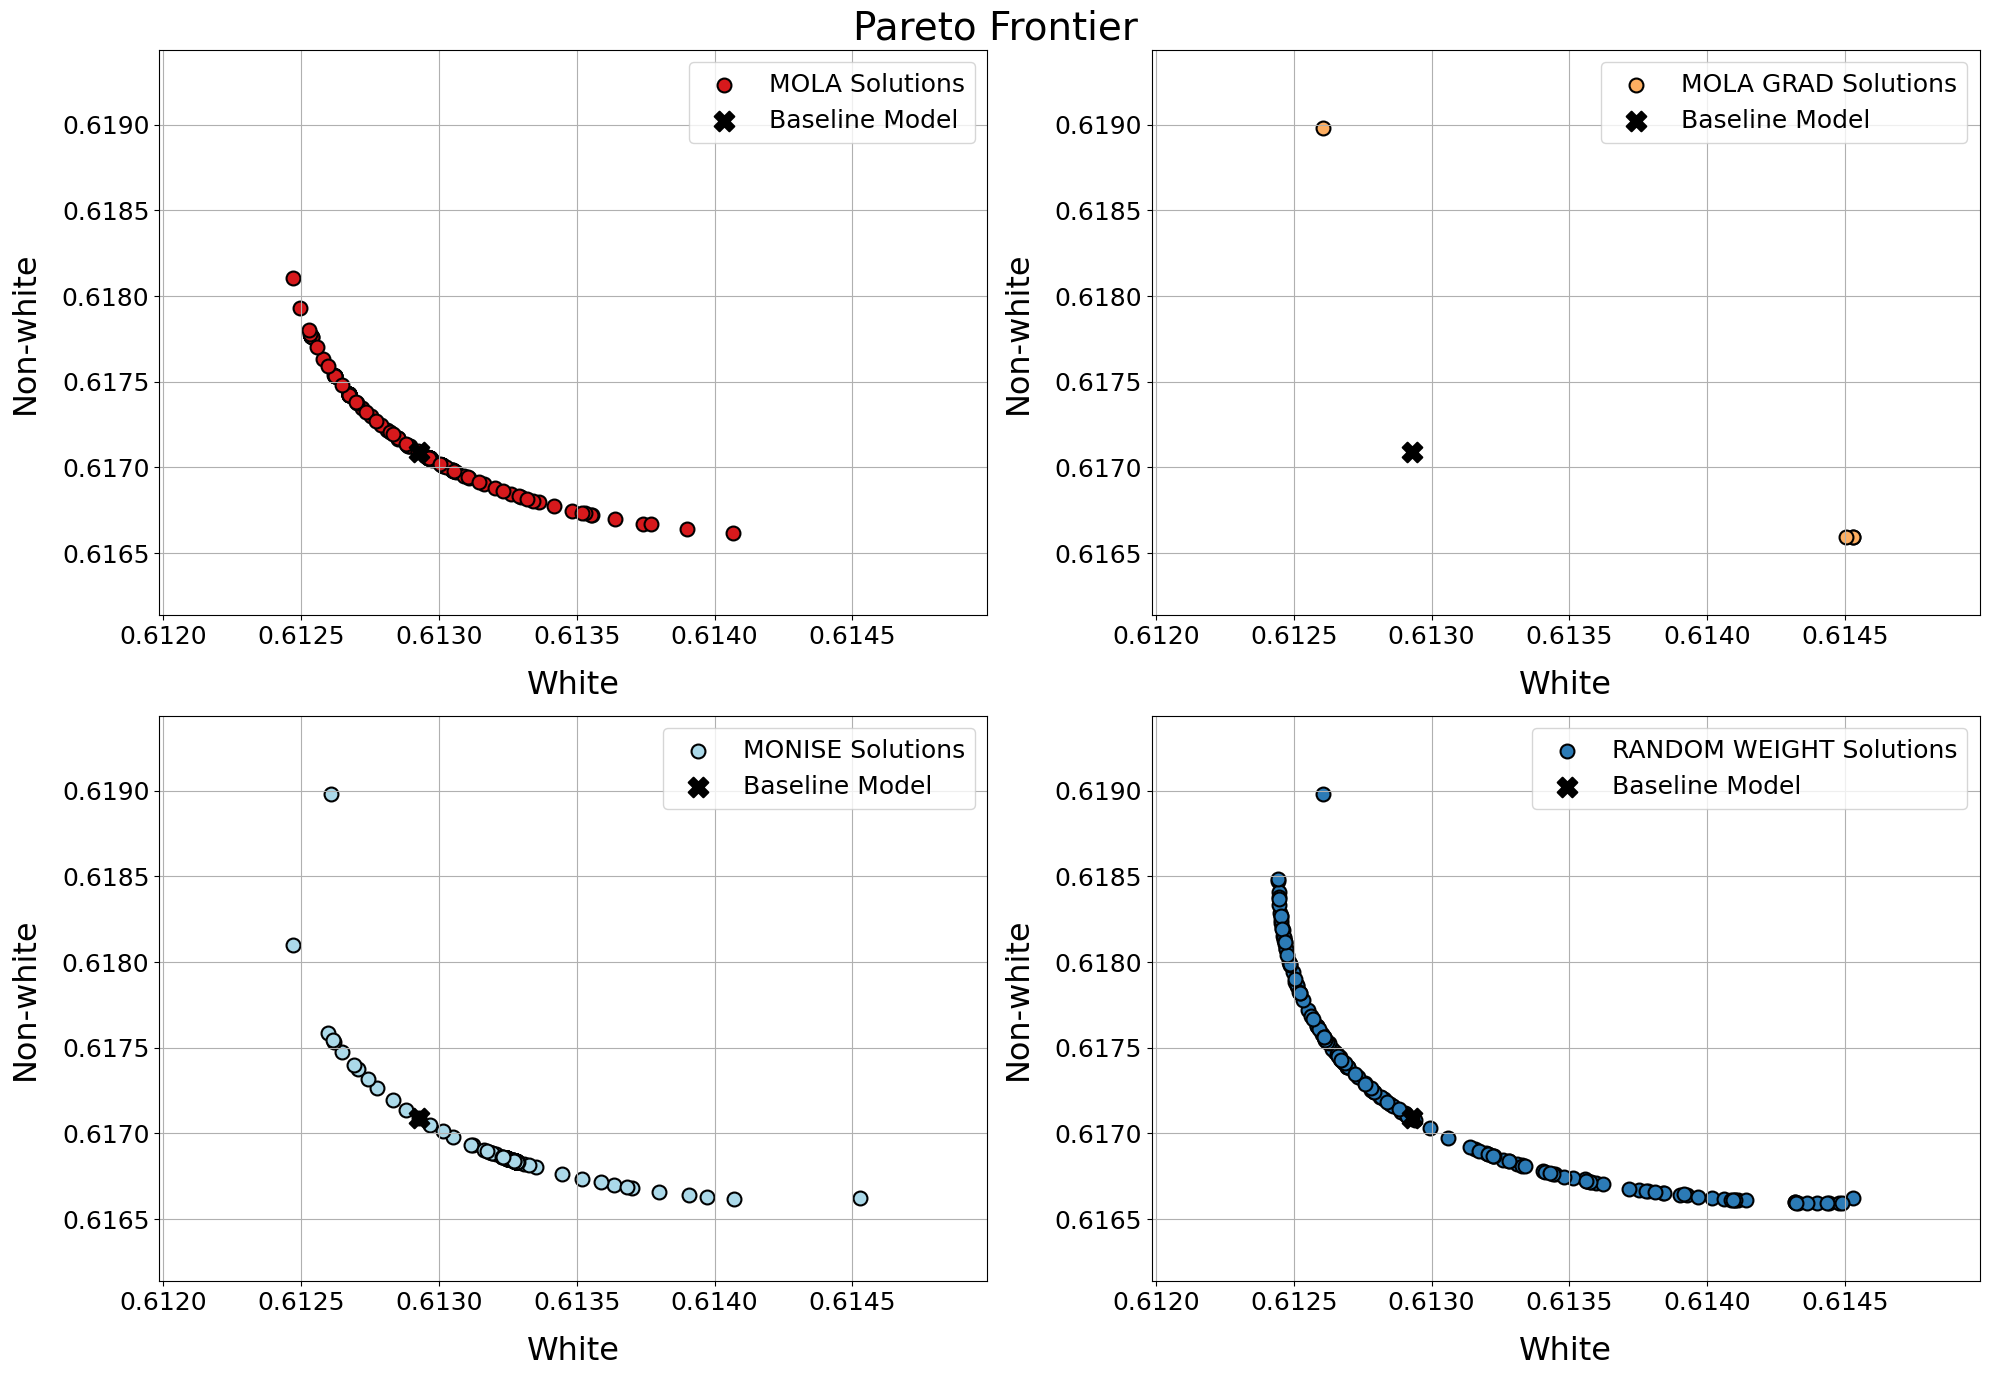

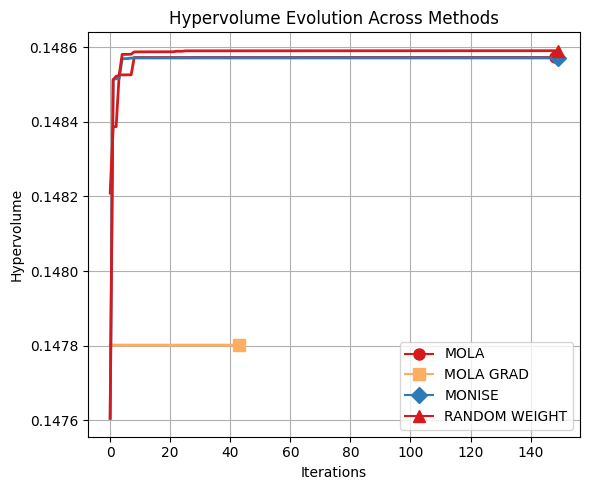

In [19]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

#colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
#colors_hv = ['#FF5C8D', '#FF5C8D', '#4BD6A0', '#9D5CFF']
#olors_hv = ['#e66101', '#fdb863', '#b2abd2', '#5e3c99']
#colors_hv = ['#ca0020', '#f4a582', '#92c5de', '#0571b0']
colors_hv = ['#d7191c', '#fdae61', '#abd9e9', '#2c7bb6']

title = ""
axes_label = ["White", "Non-White"]

plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            # title=title,
            point=equal.objs,
            color=colors_hv,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods.pdf'
            )

plot_pareto_plotly(methods=pareto_dict,
            labels=axes_label, 
            # title=title,
            point=equal.objs,
            color=colors_hv,
            fontsize=15,
            figsize=(10,7),
            save_path='images/2_objs_methods_plotly.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

### Ensemble

In [20]:
from sklearn.metrics import accuracy_score
from machinemoo import run_ensemble

In [21]:
lambd = math.exp(-100)
clf = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           max_iter = max_iter,
                           tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
#predprob = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, pred)

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [22]:
#Logistic Regression Single Objctive
print(f'Logistic Regression Accuracy: {accuracy:.4f}')

Logistic Regression Accuracy: 0.6721


In [32]:
ensembles = {}
for method in results.keys():
    ensembles[method] = {
        'acc_voting'   : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='voting'),
        'acc_baggin'   : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='baggin'),
        'acc_adaboost' : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='adaboost')
    }

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

In [33]:
for method, ensemble in ensembles.items():
    print(f'\nMethod {method.upper()}')
    print(f'  Voting Accuracy:   {ensemble["acc_voting"]:.4f}')
    print(f'  Bagging Accuracy:  {ensemble["acc_baggin"]:.4f}')
    print(f'  Adaboost Accuracy: {ensemble["acc_adaboost"]:.4f}')


Method MOLA
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6727
  Adaboost Accuracy: 0.6721

Method MOLA_GRAD
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6711
  Adaboost Accuracy: 0.6721

Method MONISE
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6682
  Adaboost Accuracy: 0.6721

Method RANDOM_WEIGHT
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6682
  Adaboost Accuracy: 0.6721


In [34]:
from sklearn.metrics import accuracy_score

In [35]:
equal_model = equal.x
predictions = equal_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"acc {accuracy}")

acc 0.6675307841866494
